In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
movies = pd.read_csv("movie.csv")
tags = pd.read_csv("tag.csv")
ratings = pd.read_csv("rating.csv")

In [17]:
print("DATA-\n","Movies-",movies.shape,
"TAGS-",tags.shape,"RATINGS-",
ratings.shape)

DATA-
 Movies- (27278, 3) TAGS- (465564, 4) RATINGS- (20000263, 4)


In [24]:
movies.head(5)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [18]:
del ratings['timestamp']
del tags['timestamp']

In [26]:
tags.head(5)

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [27]:
ratings.head(5)

,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5
2,1,32,3.5
3,1,47,3.5
4,1,50,3.5


In [19]:
print(ratings.columns)
print(tags.columns) 

Index(['userId', 'movieId', 'rating'], dtype='object')
Index(['userId', 'movieId', 'tag'], dtype='object')


In [20]:
tags.head(4)

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller


# Data Strucure:

####  Series-

In [23]:
#Select specific row in Pandas
row_0 = tags.iloc[0]
row_0

userId              18
movieId           4141
tag        Mark Waters
Name: 0, dtype: object

In [44]:
#print(row_0.index,"\nUserID-",row_0['userId'],"\nname-",row_0.name)
print(f"Index: {row_0.index}\nUser ID: {row_0['userId']}\nName: {row_0.name}")

Index: Index(['userId', 'movieId', 'tag'], dtype='object')
User ID: 18
Name: firstRow


In [41]:
row_0 = row_0.rename('firstRow')
print(row_0)

userId              18
movieId           4141
tag        Mark Waters
Name: firstRow, dtype: object


#### DataFrames

In [42]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [56]:
print(f"Index: \n{tags.index}\n Columns: {tags.columns}\n Accessing rows 0, 11, and 500: \n{tags.iloc[[0,11,500]]}")

Index: 
RangeIndex(start=0, stop=465564, step=1)
 Columns: Index(['userId', 'movieId', 'tag'], dtype='object')
 Accessing rows 0, 11, and 500: 
     userId  movieId                tag
0        18     4141        Mark Waters
11       65     1783      noir thriller
500     342    55908  entirely dialogue


In [58]:
tags.iloc[[10,100,1000]]

,userId,movieId,tag
10,65,1694,jesus
100,121,52973,drugs
1000,359,69526,needed more autobots


#### Descripting statistics

In [60]:
ratings['rating'].describe()

count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [62]:
ratings.columns

Index(['userId', 'movieId', 'rating'], dtype='object')

In [61]:
ratings.describe()

,userId,movieId,rating
count,2.000026e+07,2.000026e+07,2.000026e+07
mean,6.904587e+04,9.041567e+03,3.525529e+00
std,4.003863e+04,1.978948e+04,1.051989e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,3.439500e+04,9.020000e+02,3.000000e+00
50%,6.914100e+04,2.167000e+03,3.500000e+00
75%,1.036370e+05,4.770000e+03,4.000000e+00
max,1.384930e+05,1.312620e+05,5.000000e+00


In [63]:
ratings.corr()

,userId,movieId,rating
userId,1.000000,-0.000850,0.001175
movieId,-0.000850,1.000000,0.002606
rating,0.001175,0.002606,1.000000


### Correlation Value Interpretation

- **1.00** → Perfect positive relationship
- **0.00** → No relationship
- **-1.00** → Perfect negative relationship
  > **Note:** The closer the value is to **+1** or **-1**, the stronger the relationship. The closer it is to **0**, the weaker the relationship.

In [68]:
filter1 = ratings['rating'] > 10
#print(filter1)
print(bool(filter1.any()))

False


- This means **no rating is greater than 10**.

In [66]:
filter2 = ratings['rating'] > 0
print(bool(filter2.all()))

True


# Data Cleaning: Handling Missing Data

In [69]:
movies.shape

(27278, 3)

In [72]:
movies.isnull().any().any()

np.False_

- The **first** .any() checks within each column.
- The **second** .any() checks the results of all columns.

In [74]:
ratings.shape

(20000263, 3)

In [75]:
ratings.isnull().any().any()

np.False_

In [76]:
tags.shape

(465564, 3)

In [77]:
tags.isnull().any().any()

np.True_

- there are some tags which are NULL.

In [78]:
tags = tags.dropna()

In [79]:
tags.isnull().any().any()

np.False_

In [80]:
tags.shape

(465548, 3)

#### Data Visualization

<Axes: xlabel='rating', ylabel='Count'>

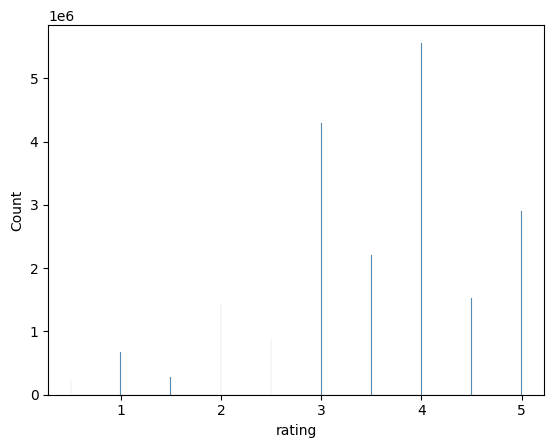

In [93]:
%matplotlib inline
#sns.histplot(data=ratings, x='rating')
sns.histplot(ratings['rating'])

<Axes: >

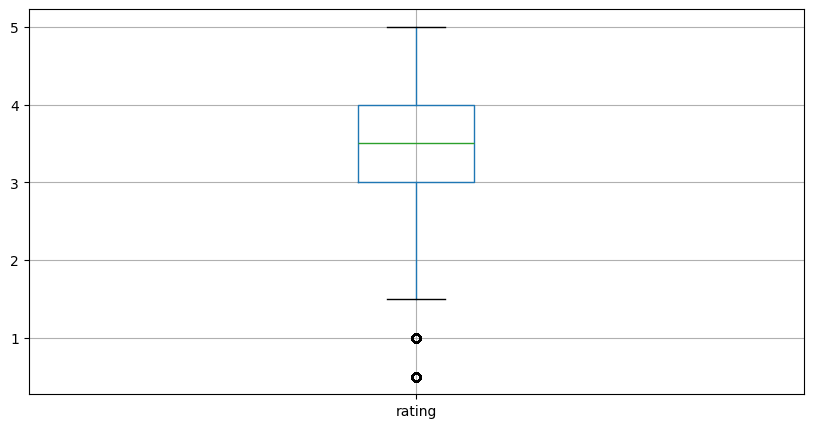

In [94]:
ratings.boxplot(column='rating', figsize=(10,5))

#### Slicing out columns

In [95]:
tags['tag'].head()

0      Mark Waters
1        dark hero
2        dark hero
3    noir thriller
4        dark hero
Name: tag, dtype: object

In [96]:
movies[['title','genres']].head()

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji (1995),Adventure|Children|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance
4,Father of the Bride Part II (1995),Comedy


In [100]:
print(rating.shape)
print(ratings[-10:])

(20000263, 4)
          userId  movieId  rating
20000253  138493    60816     4.5
20000254  138493    61160     4.0
20000255  138493    65682     4.5
20000256  138493    66762     4.5
20000257  138493    68319     4.5
20000258  138493    68954     4.5
20000259  138493    69526     4.5
20000260  138493    69644     3.0
20000261  138493    70286     5.0
20000262  138493    71619     2.5


In [104]:
tag_counts = tags['tag'].value_counts()
tag_counts[-10:]

tag
Hell naw                      1
This is my happy face         1
I heel toe on Uday's house    1
Why?                          1
Bobo                          1
Diamond Dallas Page           1
I'm Devon Butler!             1
No arguement                  1
Really Bad                    1
Botox                         1
Name: count, dtype: int64

<Axes: xlabel='tag'>

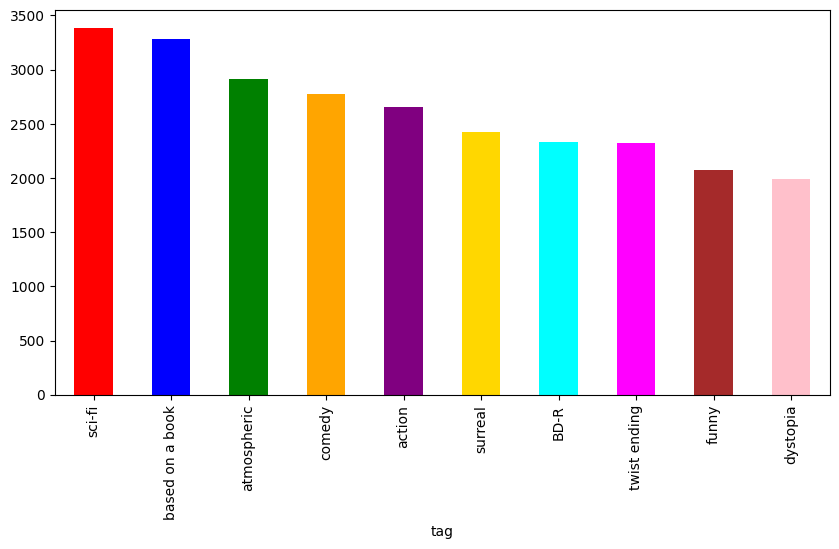

In [113]:
tag_counts[:10].plot(kind='bar',figsize=(10,5),
            color=['red','blue','green','orange','purple',
           'gold','cyan','magenta','brown','pink'])

#### Filters for Selecting Rows

In [114]:
is_highly_rated = ratings['rating'] >= 5.0
ratings[is_highly_rated][30:50]

,userId,movieId,rating
239,3,50,5.0
242,3,175,5.0
244,3,223,5.0
245,3,260,5.0
246,3,316,5.0
247,3,318,5.0
248,3,329,5.0
252,3,457,5.0
253,3,480,5.0
254,3,490,5.0
